<a href="https://colab.research.google.com/github/Ashish8000/Ashish8000/blob/main/EDA_and_Processing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **German Credit Data**

In [1]:
import pandas as pd
import numpy as np

np.random.seed(42)
n_samples = 1000

data = {
    'Age': np.random.randint(18, 75, n_samples),
    'Sex': np.random.choice(['male', 'female'], n_samples),
    'Job': np.random.choice([0, 1, 2, 3], n_samples, p=[0.2, 0.4, 0.3, 0.1]),
    'Housing': np.random.choice(['own', 'rent', 'free'], n_samples, p=[0.6, 0.3, 0.1]),
    'Saving accounts': np.random.choice(
        ['little', 'moderate', 'quite rich', 'rich', np.nan],
        n_samples, p=[0.4, 0.3, 0.1, 0.1, 0.1]
    ),
    'Checking account': np.random.choice(
        ['little', 'moderate', 'rich', np.nan],
        n_samples, p=[0.5, 0.25, 0.15, 0.1]
    ),
    'Credit amount': np.random.randint(250, 20000, n_samples),
    'Duration': np.random.randint(4, 72, n_samples),
    'Purpose': np.random.choice(
        ['car', 'furniture', 'radio/TV', 'education', 'business',
         'domestic appliances', 'repairs', 'vacation/others'],
        n_samples, p=[0.3, 0.15, 0.2, 0.1, 0.1, 0.05, 0.05, 0.05]
    )
}



def generate_risk(row):
    risk_score = 0
    if row['Age'] < 25: risk_score += 15
    elif row['Age'] > 60: risk_score += 10
    if row['Credit amount'] > 10000: risk_score += 20
    if row['Duration'] > 36: risk_score += 15
    if pd.isna(row['Saving accounts']) or row['Saving accounts'] == 'little': risk_score += 20
    if pd.isna(row['Checking account']) or row['Checking account'] == 'little': risk_score += 15
    if row['Job'] == 0: risk_score += 25
    risk_score += np.random.randint(-10, 10)
    return 'bad' if risk_score > 50 else 'good'

df = pd.DataFrame(data)
df['Risk'] = df.apply(generate_risk, axis=1)
df.to_csv('german_credit_data.csv', index=False)
print(df['Risk'].value_counts())



Risk
good    656
bad     344
Name: count, dtype: int64


# **EDA and Processing**

**Step I :** Load and Explore

In [2]:
import warnings
warnings.filterwarnings('ignore')

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("______________________________________________________")
print("The shape of the dataset is : ",df.shape)
print("______________________________________________________")
print("Sum of the NA values :\n", df.isna().sum())
print("______________________________________________________")
print("Missing Values:\n", df.isnull().sum())
print("______________________________________________________")
print("Sum of the Duplicate values :",df.duplicated().sum())
print("______________________________________________________")
print("Summary Statistics:",df.describe())
print("______________________________________________________")
print("Data Types:",df.dtypes)
print("______________________________________________________")


df.columns



______________________________________________________
The shape of the dataset is :  (1000, 10)
______________________________________________________
Sum of the NA values :
 Age                 0
Sex                 0
Job                 0
Housing             0
Saving accounts     0
Checking account    0
Credit amount       0
Duration            0
Purpose             0
Risk                0
dtype: int64
______________________________________________________
Missing Values:
 Age                 0
Sex                 0
Job                 0
Housing             0
Saving accounts     0
Checking account    0
Credit amount       0
Duration            0
Purpose             0
Risk                0
dtype: int64
______________________________________________________
Sum of the Duplicate values : 0
______________________________________________________
Summary Statistics:                Age          Job  Credit amount     Duration
count  1000.000000  1000.000000    1000.000000  1000.000000
mean

Index(['Age', 'Sex', 'Job', 'Housing', 'Saving accounts', 'Checking account',
       'Credit amount', 'Duration', 'Purpose', 'Risk'],
      dtype='object')

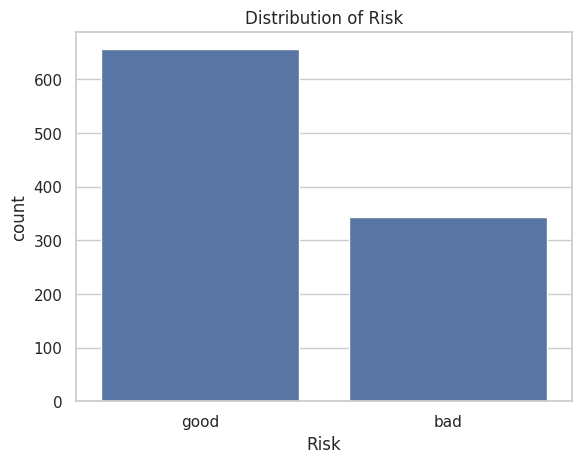

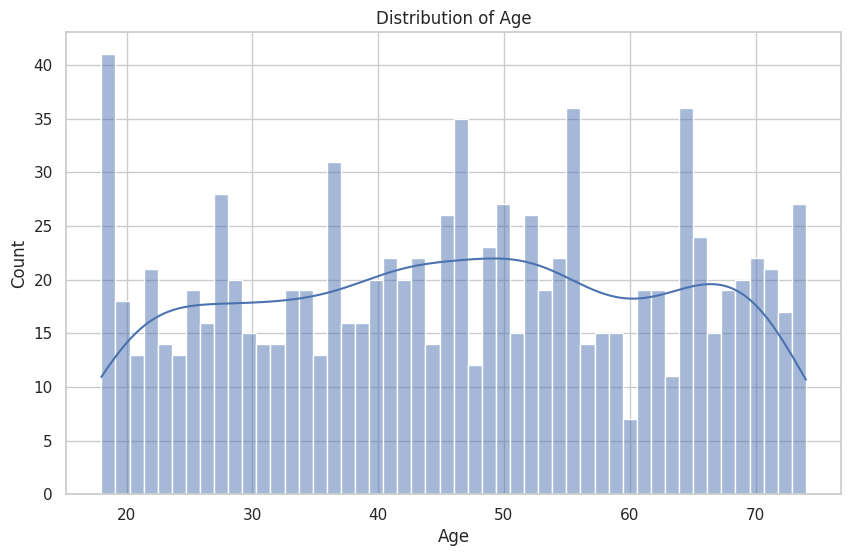

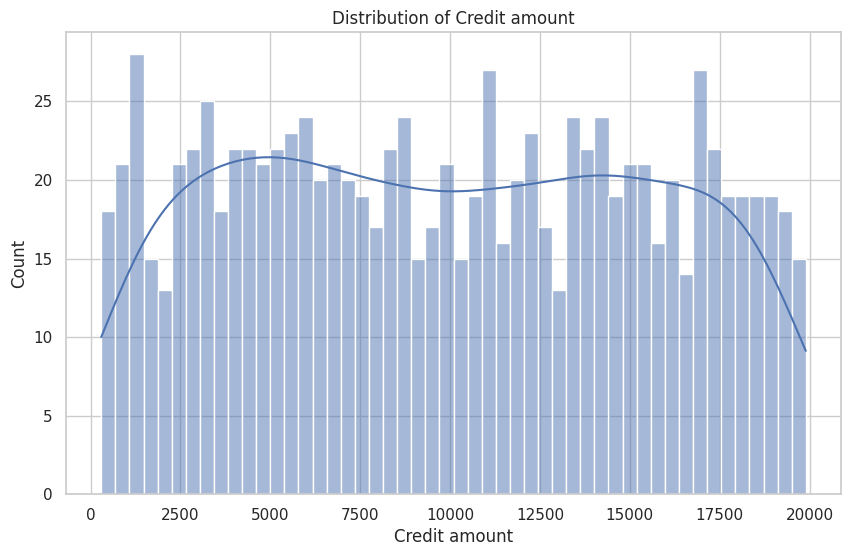

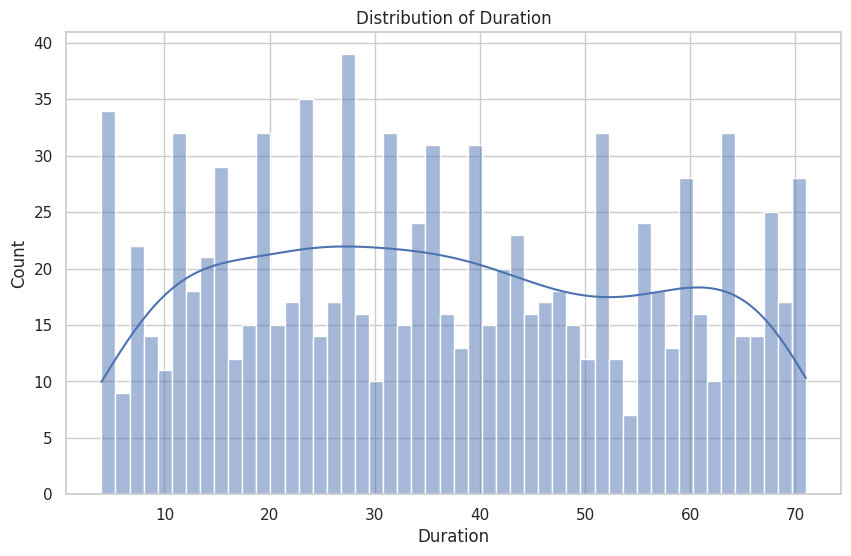

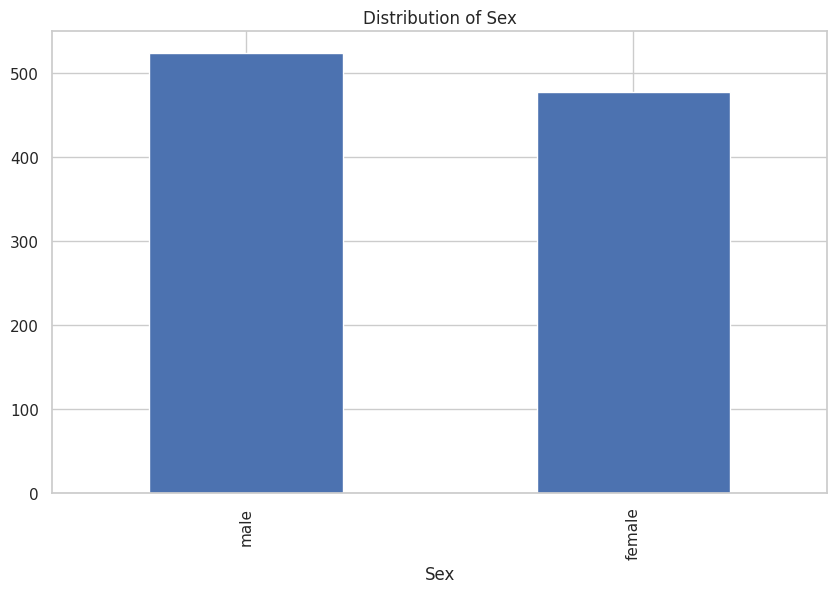

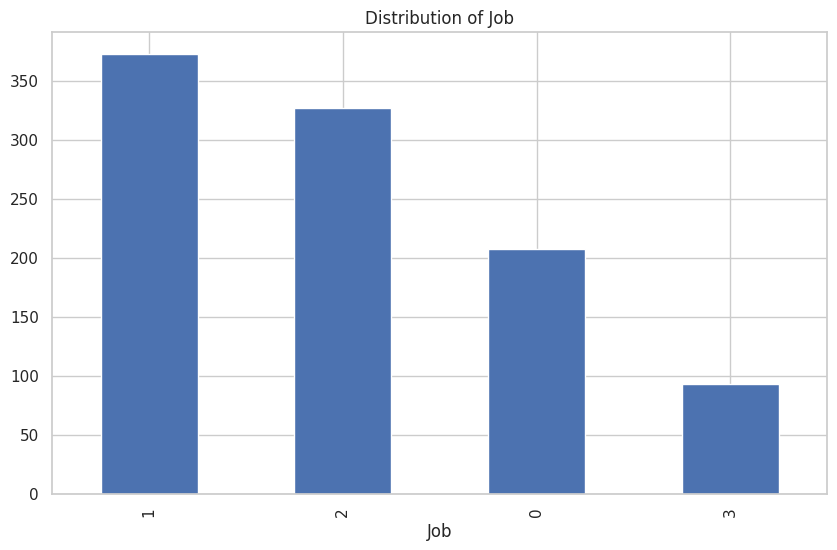

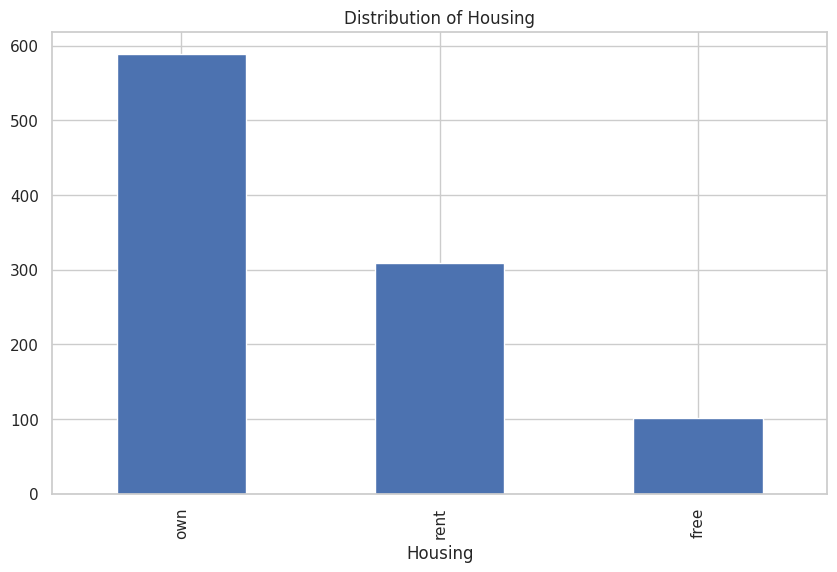

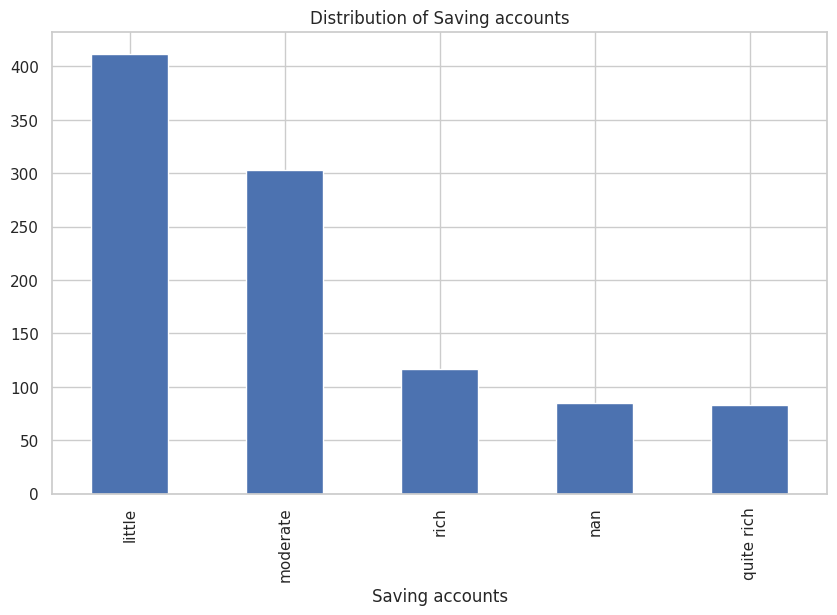

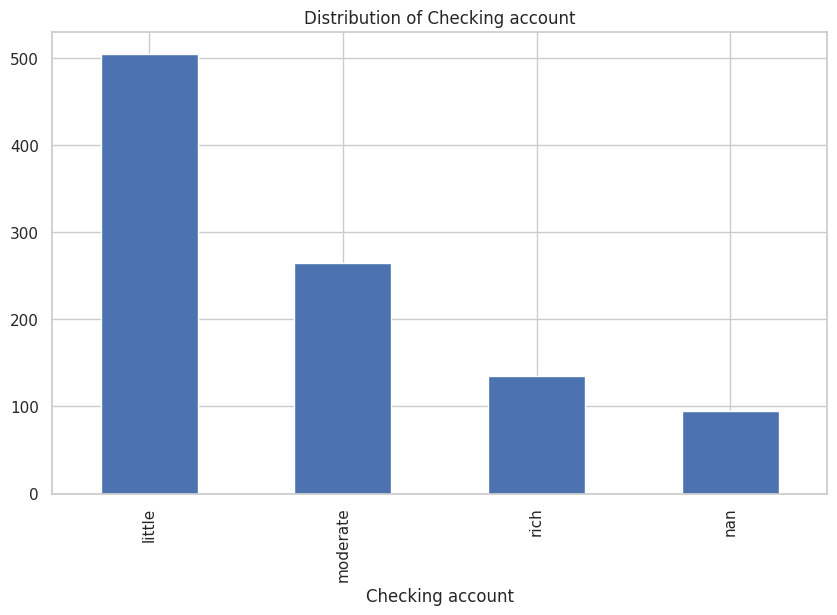

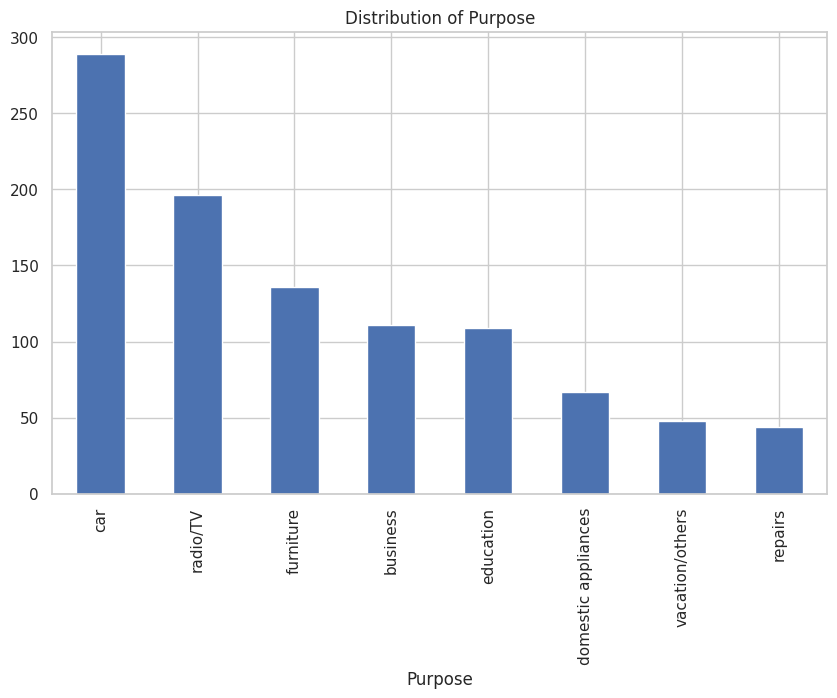

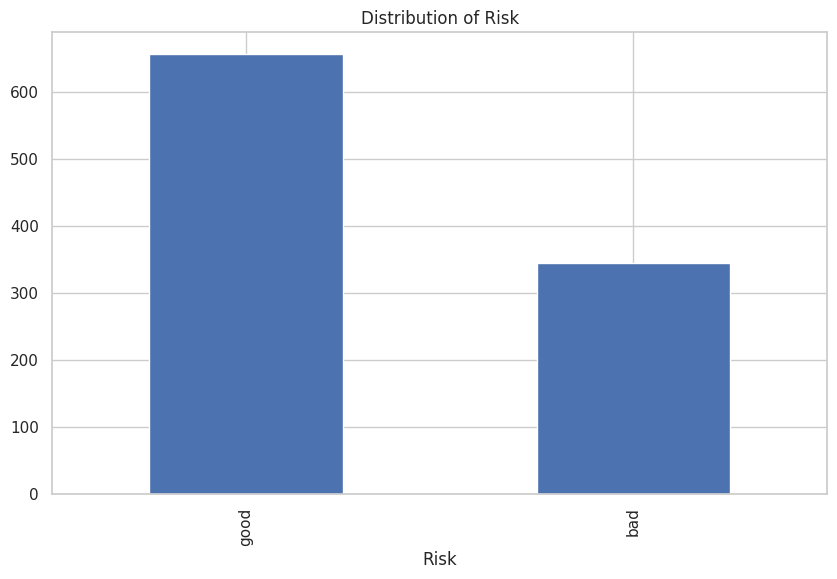

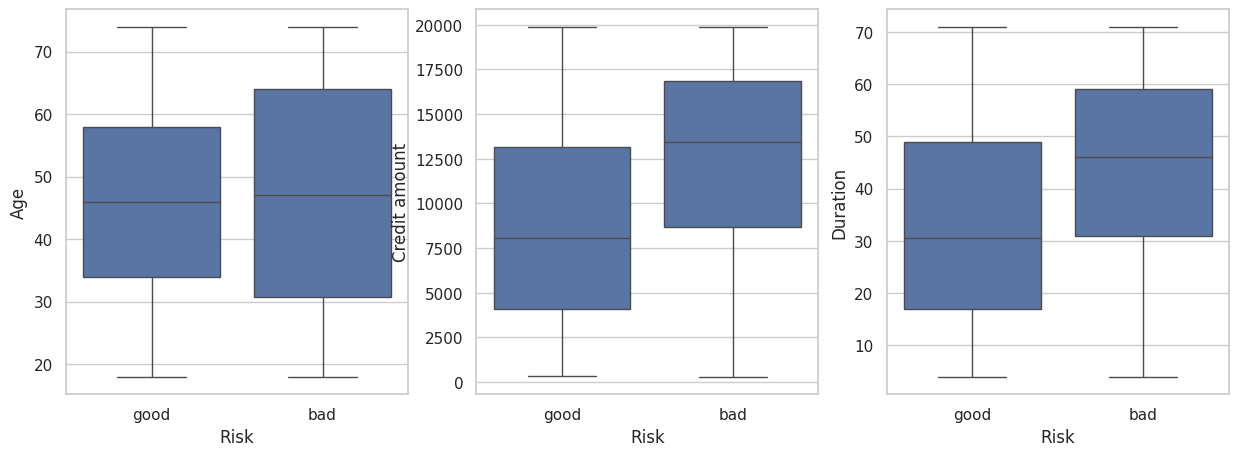

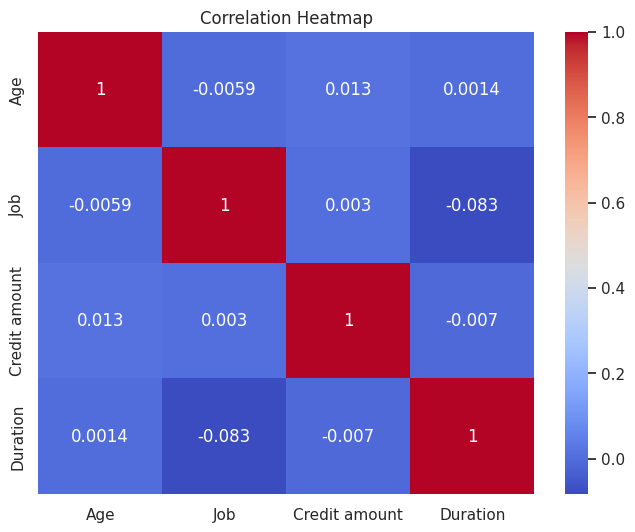

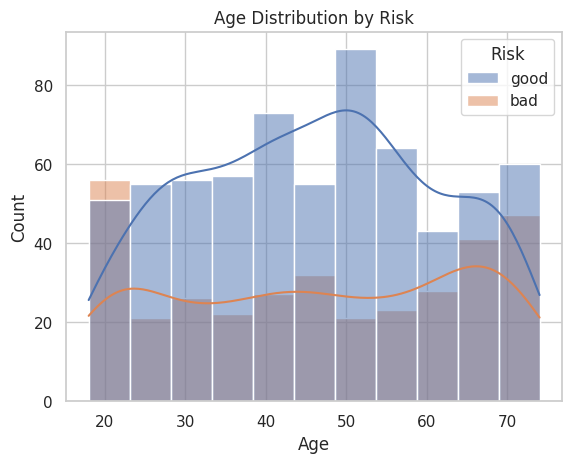

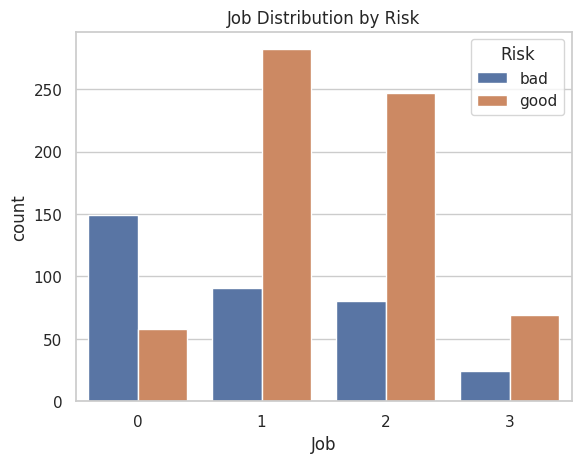

,0
Saving accounts,0
Checking account,0


In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

# Risk distribution Good or Bad
sns.countplot(x='Risk', data=df)
plt.title("Distribution of Risk")
plt.show()

# Histogram over numerical features

numeric_columns = ['Age', 'Credit amount', 'Duration']

for cols in numeric_columns:
    plt.figure(figsize=(10, 6))
    sns.histplot(df[cols], bins=50, kde=True)
    plt.title(f'Distribution of {cols}')
    plt.show()


# Histogram over categorical features

categorical_columns = ['Sex', 'Job', 'Housing', 'Saving accounts', 'Checking account', 'Purpose', 'Risk']

for cols in categorical_columns:
  plt.figure(figsize=(10, 6))
  df[cols].value_counts().plot(kind='bar')
  plt.title(f'Distribution of {cols}')
  plt.show()

# Box plots by Risk
plt.figure(figsize=(15,5))
plt.subplot(1,3,1)
sns.boxplot(x='Risk', y='Age', data=df)
plt.subplot(1,3,2)
sns.boxplot(x='Risk', y='Credit amount', data=df)
plt.subplot(1,3,3)
sns.boxplot(x='Risk', y='Duration', data=df)
plt.show()

# Correlation Heatmap
plt.figure(figsize=(8,6))
corr = df.corr(numeric_only=True)
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()


# Age distribution by Risk
sns.histplot(data=df, x='Age', hue='Risk', kde=True)
plt.title("Age Distribution by Risk")
plt.show()

# Job distribution by Risk
sns.countplot(data=df, x='Job', hue='Risk')
plt.title("Job Distribution by Risk")
plt.show()

# Filling NA with Unknown
df['Saving accounts'] = df['Saving accounts'].fillna('unknown')
df['Checking account'] = df['Checking account'].fillna('unknown')
df[['Saving accounts', 'Checking account']].isna().sum()